# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from process_bank_churn import preprocess_data, preprocess_new_data
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
import time

## Functions for automation

In [2]:
def classify_analysis(targets, inputs, model, name = ''):

    pred = model.predict(inputs)
    pred_proba = model.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 4)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()


In [3]:
def importance_features(X_train, model, n=10):
    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values('importance', ascending = False).round(4)

    print(f"TOP-{n} найважливіших ознак")
    display(importance_df.head(n))

    plt.title('Feature Importance')
    sns.barplot(data = importance_df.head(10), x = 'importance', y = 'feature');

## Loading data

In [4]:
raw_df = pd.read_csv('train.csv')

In [5]:
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [6]:
target_col = 'Exited'
inputs_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
map_cols = ['Gender']
encoder_cols = ['Geography']
map_codes = {'Female': 1, 'Male': 0}

In [7]:
preprodessed_train_df = preprocess_data(raw_df, target_col, inputs_cols, map_cols, map_codes, encoder_cols, scaler_numeric=True)

In [8]:
X_train = preprodessed_train_df['X_train']
X_val = preprodessed_train_df['X_val']
train_targets = preprodessed_train_df['y_train']
val_targets = preprodessed_train_df['y_val']
encoder = preprodessed_train_df['encoder']
scaler = preprodessed_train_df['scaler']

In [9]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
7180,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,1.0,0.0,0.0
10393,0.347838,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,1.0,0.0,0.0
80,0.638166,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,0.0,1.0,0.0
3365,0.140460,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,0.0,0.0,1.0
12236,0.665816,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,1.0,0.0,0.0


# kNN model

In [10]:
knn_base = KNeighborsClassifier()
knn_base.fit(X_train, train_targets)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


F1 score on Training: 0.7613
AUROC for Training: 0.962


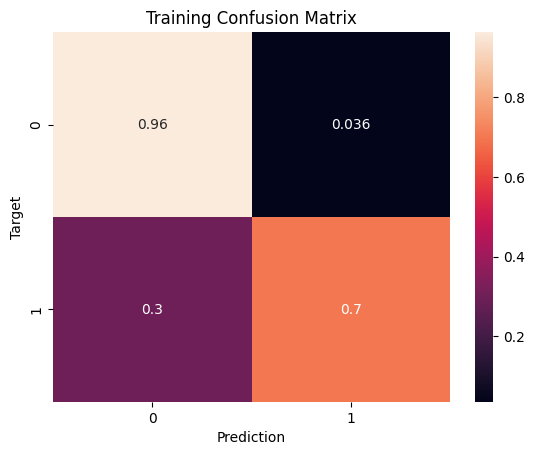

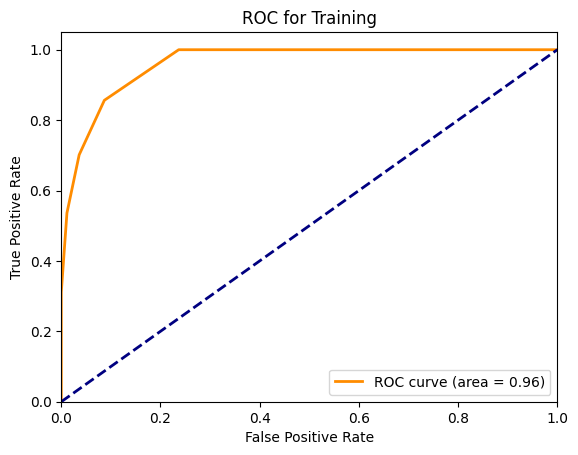

In [11]:
classify_analysis(train_targets, X_train, knn_base, 'Training')

F1 score on Validation: 0.6422
AUROC for Validation: 0.8725


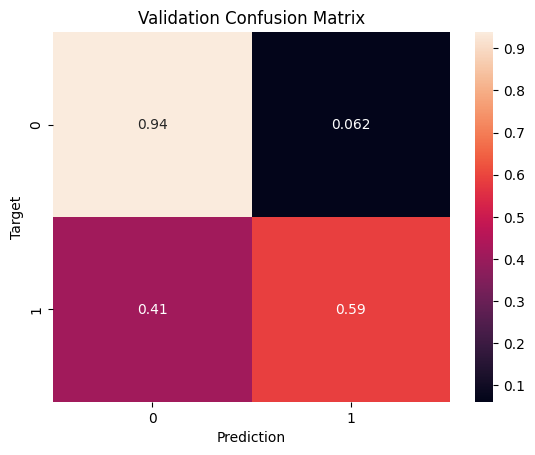

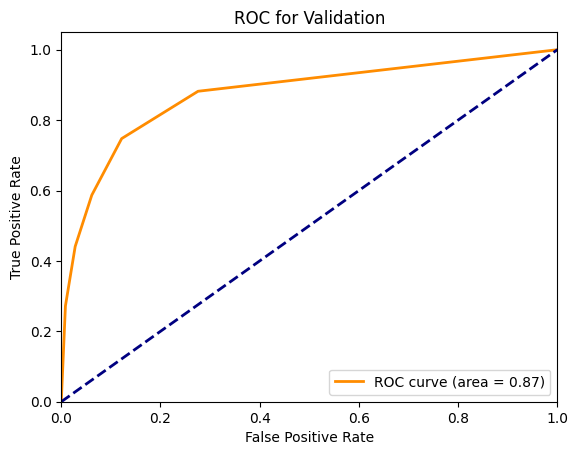

In [12]:
classify_analysis(val_targets, X_val, knn_base, 'Validation')

The training results of the basic KNN model show a good value of the target metric (AUROC 0.8725 on the validation data), however, there is probably overfitting, which is reflected in the excess of the area under the AUC curve on the training sample over the value of the validation sample. Accordingly, we have a high variance.

## kNN and GridSearchCV

In [13]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1,35)}
knn_gs = GridSearchCV(knn, params_knn, cv = 5)
knn_gs.fit(X_train, train_targets)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2..., 32, 33, 34])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [14]:
knn_best = knn_gs.best_estimator_
print('Кількість сусідів:', knn_gs.best_params_['n_neighbors'])

Кількість сусідів: 9


F1 score on Training: 0.7286
AUROC for Training: 0.9502


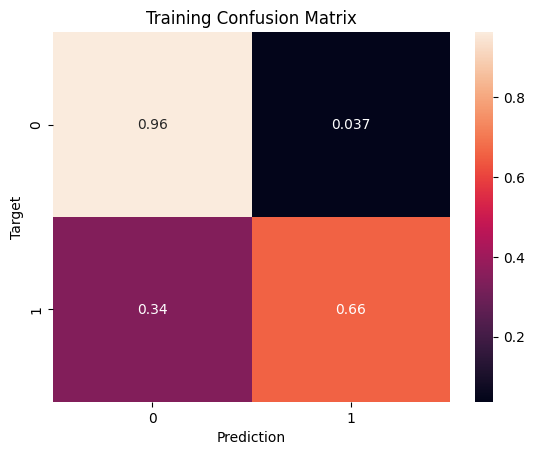

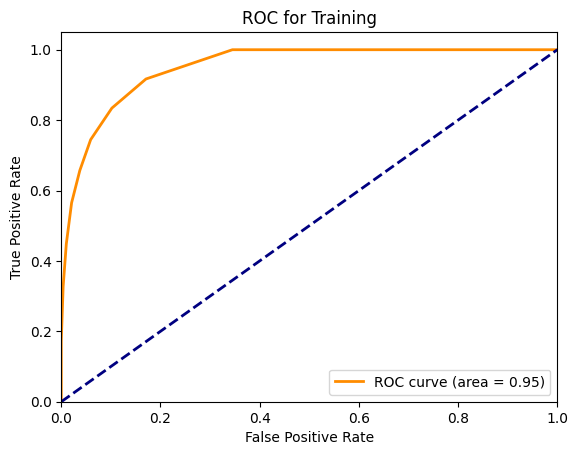

In [15]:
classify_analysis(train_targets, X_train, knn_best, 'Training')

F1 score on Validation: 0.663
AUROC for Validation: 0.8941


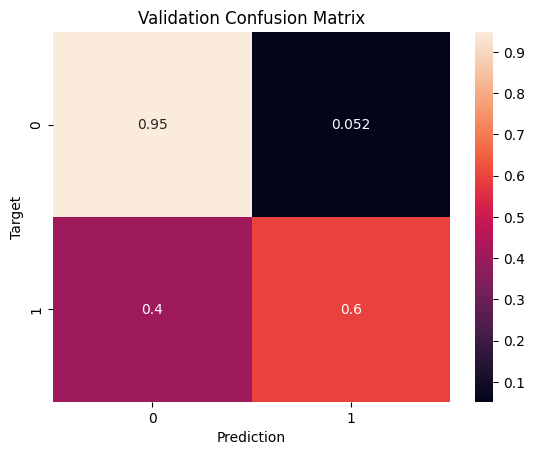

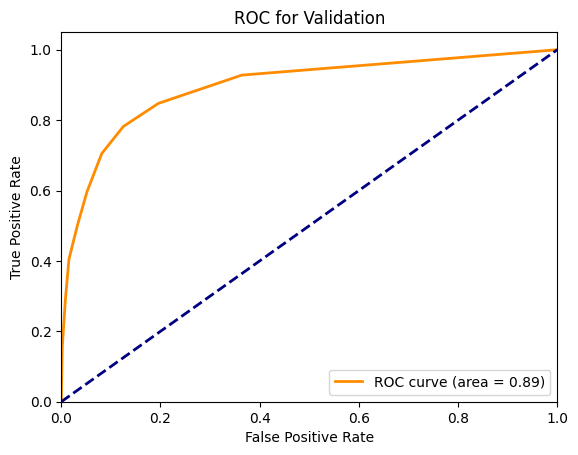

In [16]:
classify_analysis(val_targets, X_val, knn_best, 'Validation')

The model with the selected number of neighbors -- 9, demonstrates better results on the validation sample compared to the previous model, but the excess of AUROC on the training sample is maintained.

However, a result equal to or exceeding that obtained in the previous work with decision trees (0.9203) has not yet been achieved.

# DecisionTreeClassifier and GridSearchCV

In [17]:
dt = DecisionTreeClassifier(random_state = 42)
params_dt_GS = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11)
}
dt_gs = GridSearchCV(dt, params_dt_GS, cv = 3, scoring = 'roc_auc')

start = time.time()

dt_gs.fit(X_train, train_targets)

end = time.time()
print(f'Time: {round(end - start, 2)} s')

Time: 4.83 s


In [18]:
dt_best = dt_gs.best_estimator_

print(f'Максимальна глибина дерева: {dt_gs.best_params_['max_depth']}.')
print(f'Максимальна кількість листків: {dt_gs.best_params_['max_leaf_nodes']}.')

Максимальна глибина дерева: 5.
Максимальна кількість листків: 10.


F1 score on Training: 0.67
AUROC for Training: 0.9015


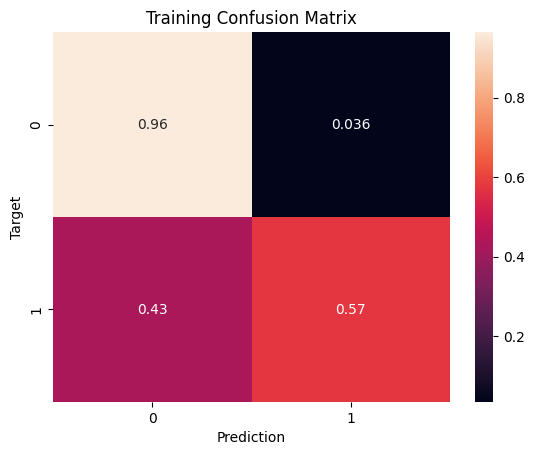

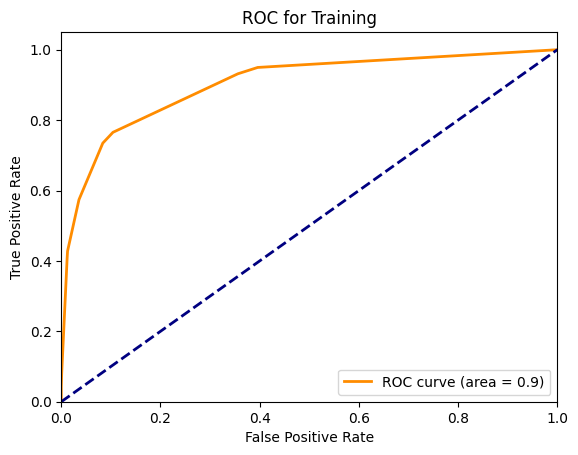

In [19]:
classify_analysis(train_targets, X_train, dt_best, 'Training')

F1 score on Validation: 0.6506
AUROC for Validation: 0.9002


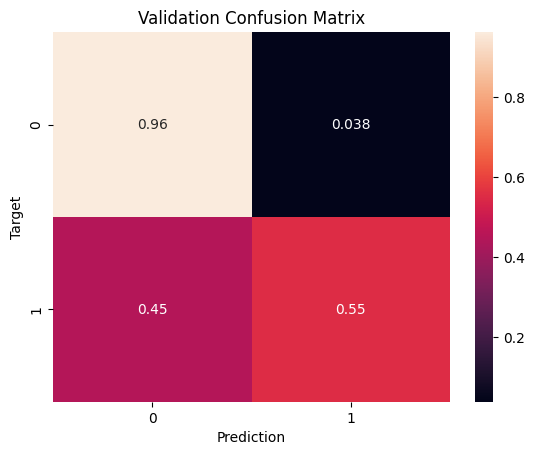

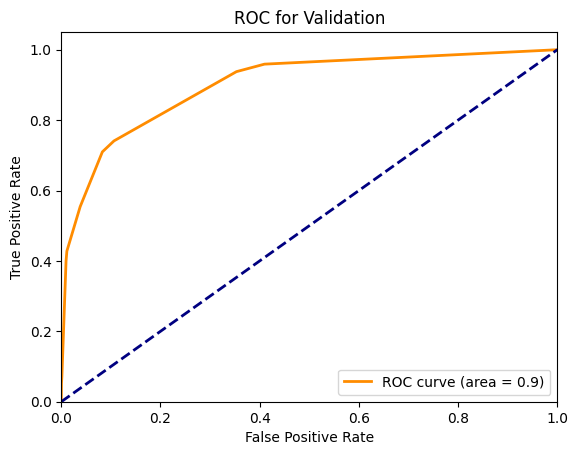

In [20]:
classify_analysis(val_targets, X_val, dt_best, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.6057
4,NumOfProducts,0.3526
6,IsActiveMember,0.0417
2,Tenure,0.0000
0,CreditScore,0.0000
3,Balance,0.0000
5,HasCrCard,0.0000
7,EstimatedSalary,0.0000
8,Geography_France,0.0000
9,Geography_Germany,0.0000


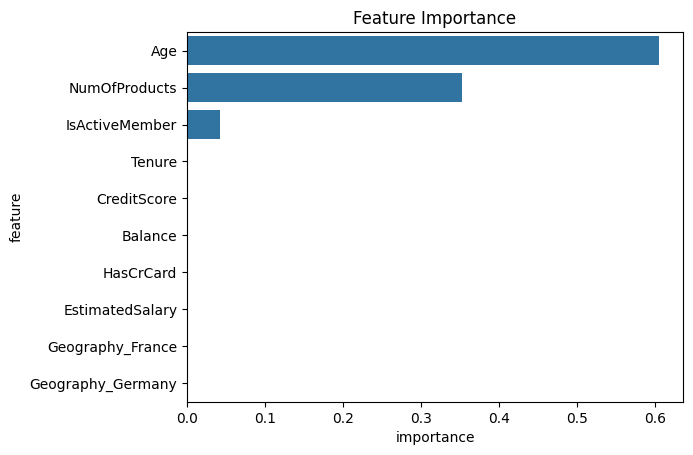

In [21]:
importance_features(X_train, dt_best)

Compared to all models in the current Jupyter Notebook, the model with the selected number of leaves and depth has the best and most stable result (0.9002 on the validation set), but still does not reach the quality level of the model built in the previous work (tree depth: 5, number of tree nodes: 57, AUROC on validation 0.9203).

It is worth noting that the 3 most important factors for both this model and the decision tree of the previous work are the same.

# DecisionTreeClassifier and RandomizedSearchCV

In [22]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [23]:
dt_random = RandomizedSearchCV(dt, params_dt, n_iter = 40, cv = 3, scoring = 'roc_auc', random_state = 42)

start_rs = time.time()

dt_rs = dt_random.fit(X_train, train_targets)

end_rs = time.time()
print(f'Time: {round(end_rs - start_rs, 2)} s')

Time: 1.36 s


In [24]:
dt_random_search_best = dt_rs.best_estimator_

print(f"Інформаційний критерій: {dt_rs.best_params_['criterion']}.")
print(f"Метод поділу: {dt_rs.best_params_['splitter']}.")
print(f"Максимальна глибина дерева: {dt_rs.best_params_['max_depth']}.")
print(f"Максимальна кількість листків: {dt_rs.best_params_['max_leaf_nodes']}.")
print(f"Мінімальна кількість зразків для поділу вузла: {dt_rs.best_params_['min_samples_split']}.")
print(f"Мінімальна кількість зразків у листку: {dt_rs.best_params_['min_samples_leaf']}.")
print(f"Максимальна кількість ознак для поділу: {dt_rs.best_params_['max_features']}.")

Інформаційний критерій: entropy.
Метод поділу: best.
Максимальна глибина дерева: 16.
Максимальна кількість листків: 14.
Мінімальна кількість зразків для поділу вузла: 20.
Мінімальна кількість зразків у листку: 2.
Максимальна кількість ознак для поділу: None.


F1 score on Training: 0.7022
AUROC for Training: 0.9169


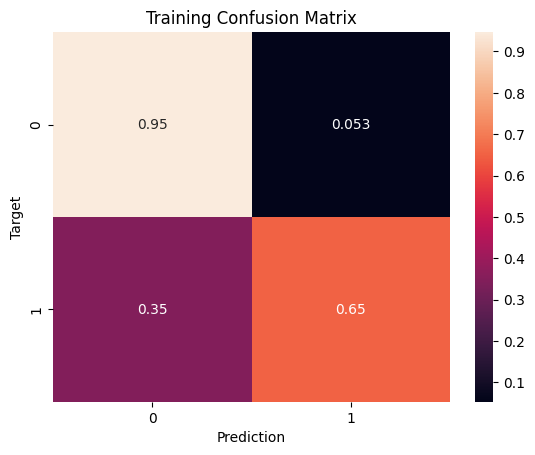

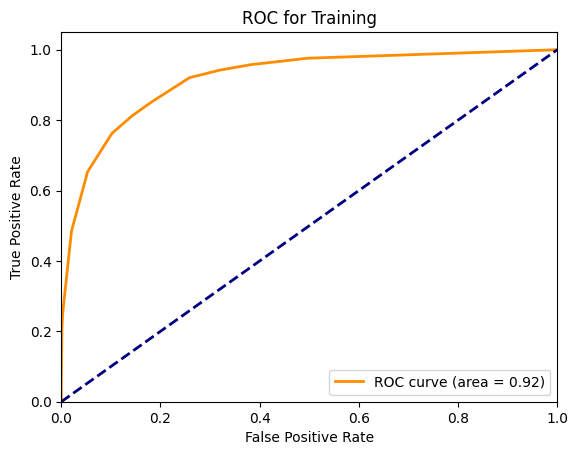

In [25]:
classify_analysis(train_targets, X_train, dt_random_search_best, 'Training')

F1 score on Validation: 0.69
AUROC for Validation: 0.9166


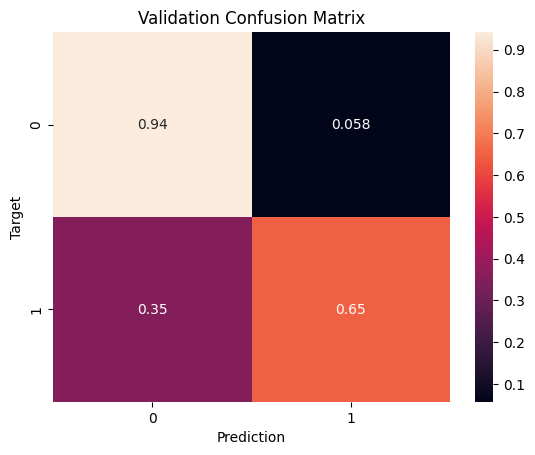

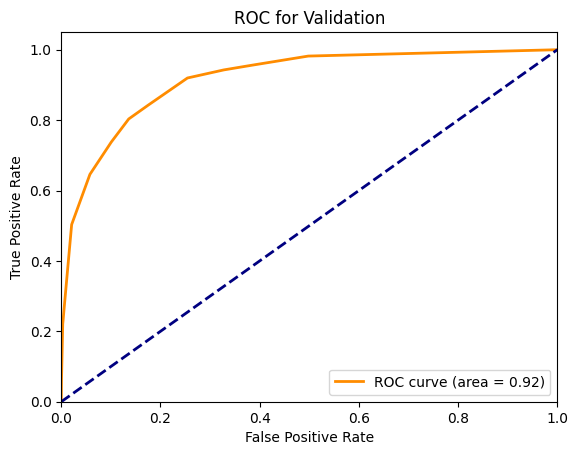

In [26]:
classify_analysis(val_targets, X_val, dt_random_search_best, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.5255
4,NumOfProducts,0.3916
6,IsActiveMember,0.0424
3,Balance,0.0305
9,Geography_Germany,0.0101
2,Tenure,0.0000
0,CreditScore,0.0000
5,HasCrCard,0.0000
7,EstimatedSalary,0.0000
8,Geography_France,0.0000


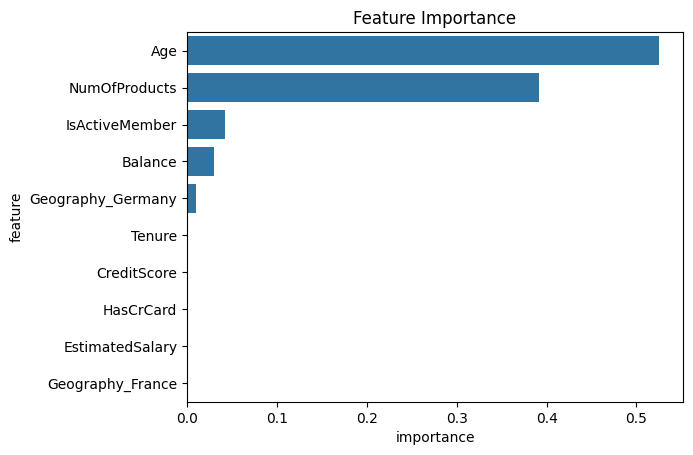

In [27]:
importance_features(X_train, dt_random_search_best)

This model, as with the selected parameters through GridSearchCV, shows a stable result, while it is slightly better, however, it still does not exceed the decision tree of the previous homework.

The depth of the tree and the number of leaves have increased compared to GridSearchCV, but the time for selecting parameters is half as long.

In [28]:
params_dt_2 = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 70),
    'max_leaf_nodes': np.arange(2, 70),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [29]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

dt_random_2 = RandomizedSearchCV(dt, params_dt_2, n_iter = 60, cv = cv, scoring = 'roc_auc', random_state = 42)

start_rs_2 = time.time()

dt_rs_2 = dt_random_2.fit(X_train, train_targets)

end_rs_2 = time.time()
print(f'Time: {round(end_rs_2 - start_rs_2, 2)} s')

Time: 3.96 s


In [30]:
dt_random_search_best_2 = dt_rs_2.best_estimator_

print(f"Інформаційний критерій: {dt_rs_2.best_params_['criterion']}.")
print(f"Метод поділу: {dt_rs_2.best_params_['splitter']}.")
print(f"Максимальна глибина дерева: {dt_rs_2.best_params_['max_depth']}.")
print(f"Максимальна кількість листків: {dt_rs_2.best_params_['max_leaf_nodes']}.")
print(f"Мінімальна кількість зразків для поділу вузла: {dt_rs_2.best_params_['min_samples_split']}.")
print(f"Мінімальна кількість зразків у листку: {dt_rs_2.best_params_['min_samples_leaf']}.")
print(f"Максимальна кількість ознак для поділу: {dt_rs_2.best_params_['max_features']}.")

Інформаційний критерій: entropy.
Метод поділу: best.
Максимальна глибина дерева: 44.
Максимальна кількість листків: 34.
Мінімальна кількість зразків для поділу вузла: 10.
Мінімальна кількість зразків у листку: 4.
Максимальна кількість ознак для поділу: None.


F1 score on Training: 0.7345
AUROC for Training: 0.9313


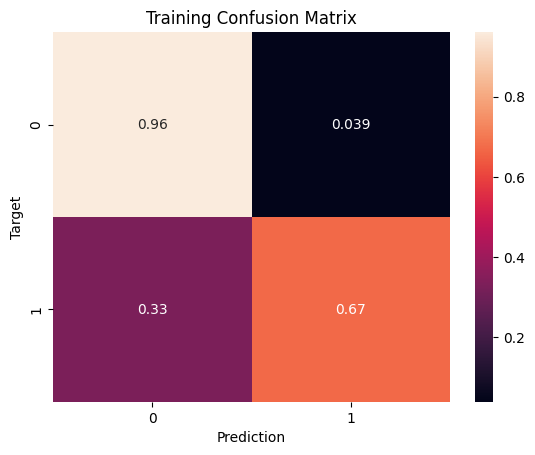

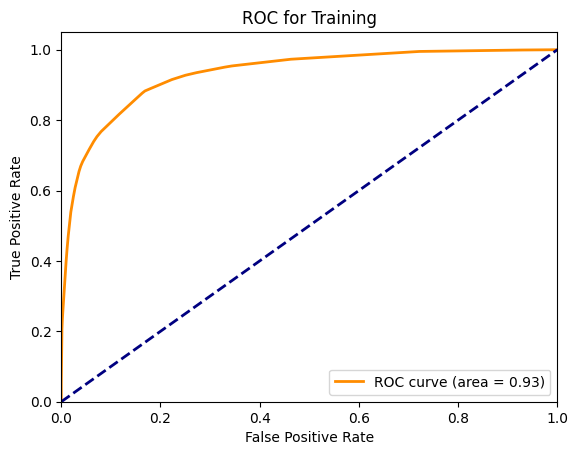

In [31]:
classify_analysis(train_targets, X_train, dt_random_search_best_2, 'Training')

F1 score on Validation: 0.7177
AUROC for Validation: 0.9242


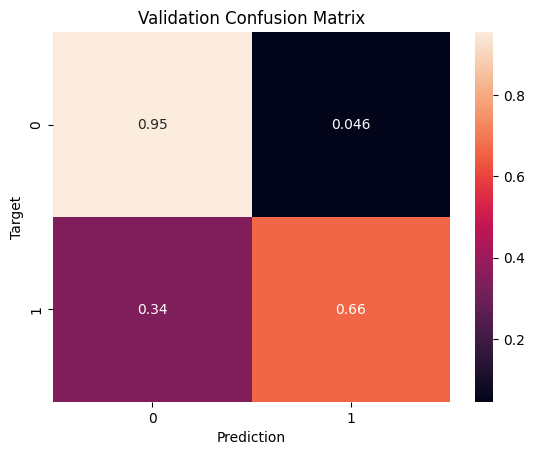

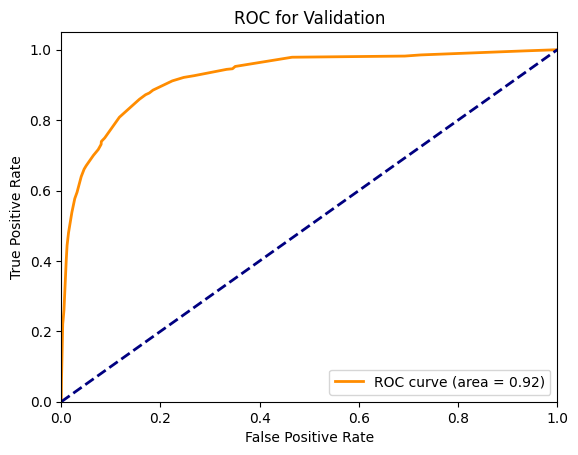

In [32]:
classify_analysis(val_targets, X_val, dt_random_search_best_2, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.4969
4,NumOfProducts,0.3574
3,Balance,0.0579
6,IsActiveMember,0.0494
9,Geography_Germany,0.0310
0,CreditScore,0.0051
2,Tenure,0.0024
5,HasCrCard,0.0000
7,EstimatedSalary,0.0000
8,Geography_France,0.0000


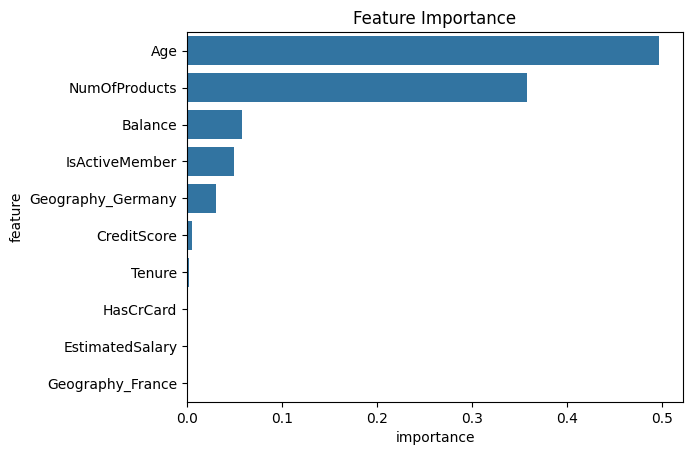

In [33]:
importance_features(X_train, dt_random_search_best_2)

After expanding the depth and number of leaves for parameter search, as well as applying StratifiedKFold, a fairly good and slightly higher AUROC result was obtained on the validation sample, even compared to the model in the previous pre-test task. Therefore, we will check its results on the competition test dataset.

In [34]:
test_df = pd.read_csv('test.csv')
test_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [35]:
X_test = preprocess_new_data(test_df, inputs_cols, map_cols, map_codes, encoder_cols, encoder, scaler)
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,-1.034678,-0.944682,-1.087792,1.720173,-1.108193,0.515062,1.016977,0.875226,0.0,1.0,0.0
1,-1.490909,0.161227,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.109098,1.0,0.0,0.0
2,0.651991,0.652742,1.069040,-0.717950,0.769304,0.515062,-0.983306,0.850584,1.0,0.0,0.0
3,0.804068,0.898500,-0.728320,-0.717950,-1.108193,0.515062,1.016977,1.073044,0.0,0.0,1.0
4,-0.924077,0.652742,1.069040,-0.717950,0.769304,0.515062,1.016977,0.563521,0.0,0.0,1.0


In [36]:
test_df['Exited'] = dt_random_search_best_2.predict_proba(X_test)[:,1]

In [37]:
submission = pd.read_csv('sample_submission.csv')

In [38]:
submission['Exited'] = test_df['Exited']

In [39]:
submission.head()

,id,Exited
0,15000,0.043478
1,15001,0.021354
2,15002,0.077586
3,15003,0.768519
4,15004,0.065858


In [40]:
submission.to_csv('submission_dt_rs.csv', index = False)

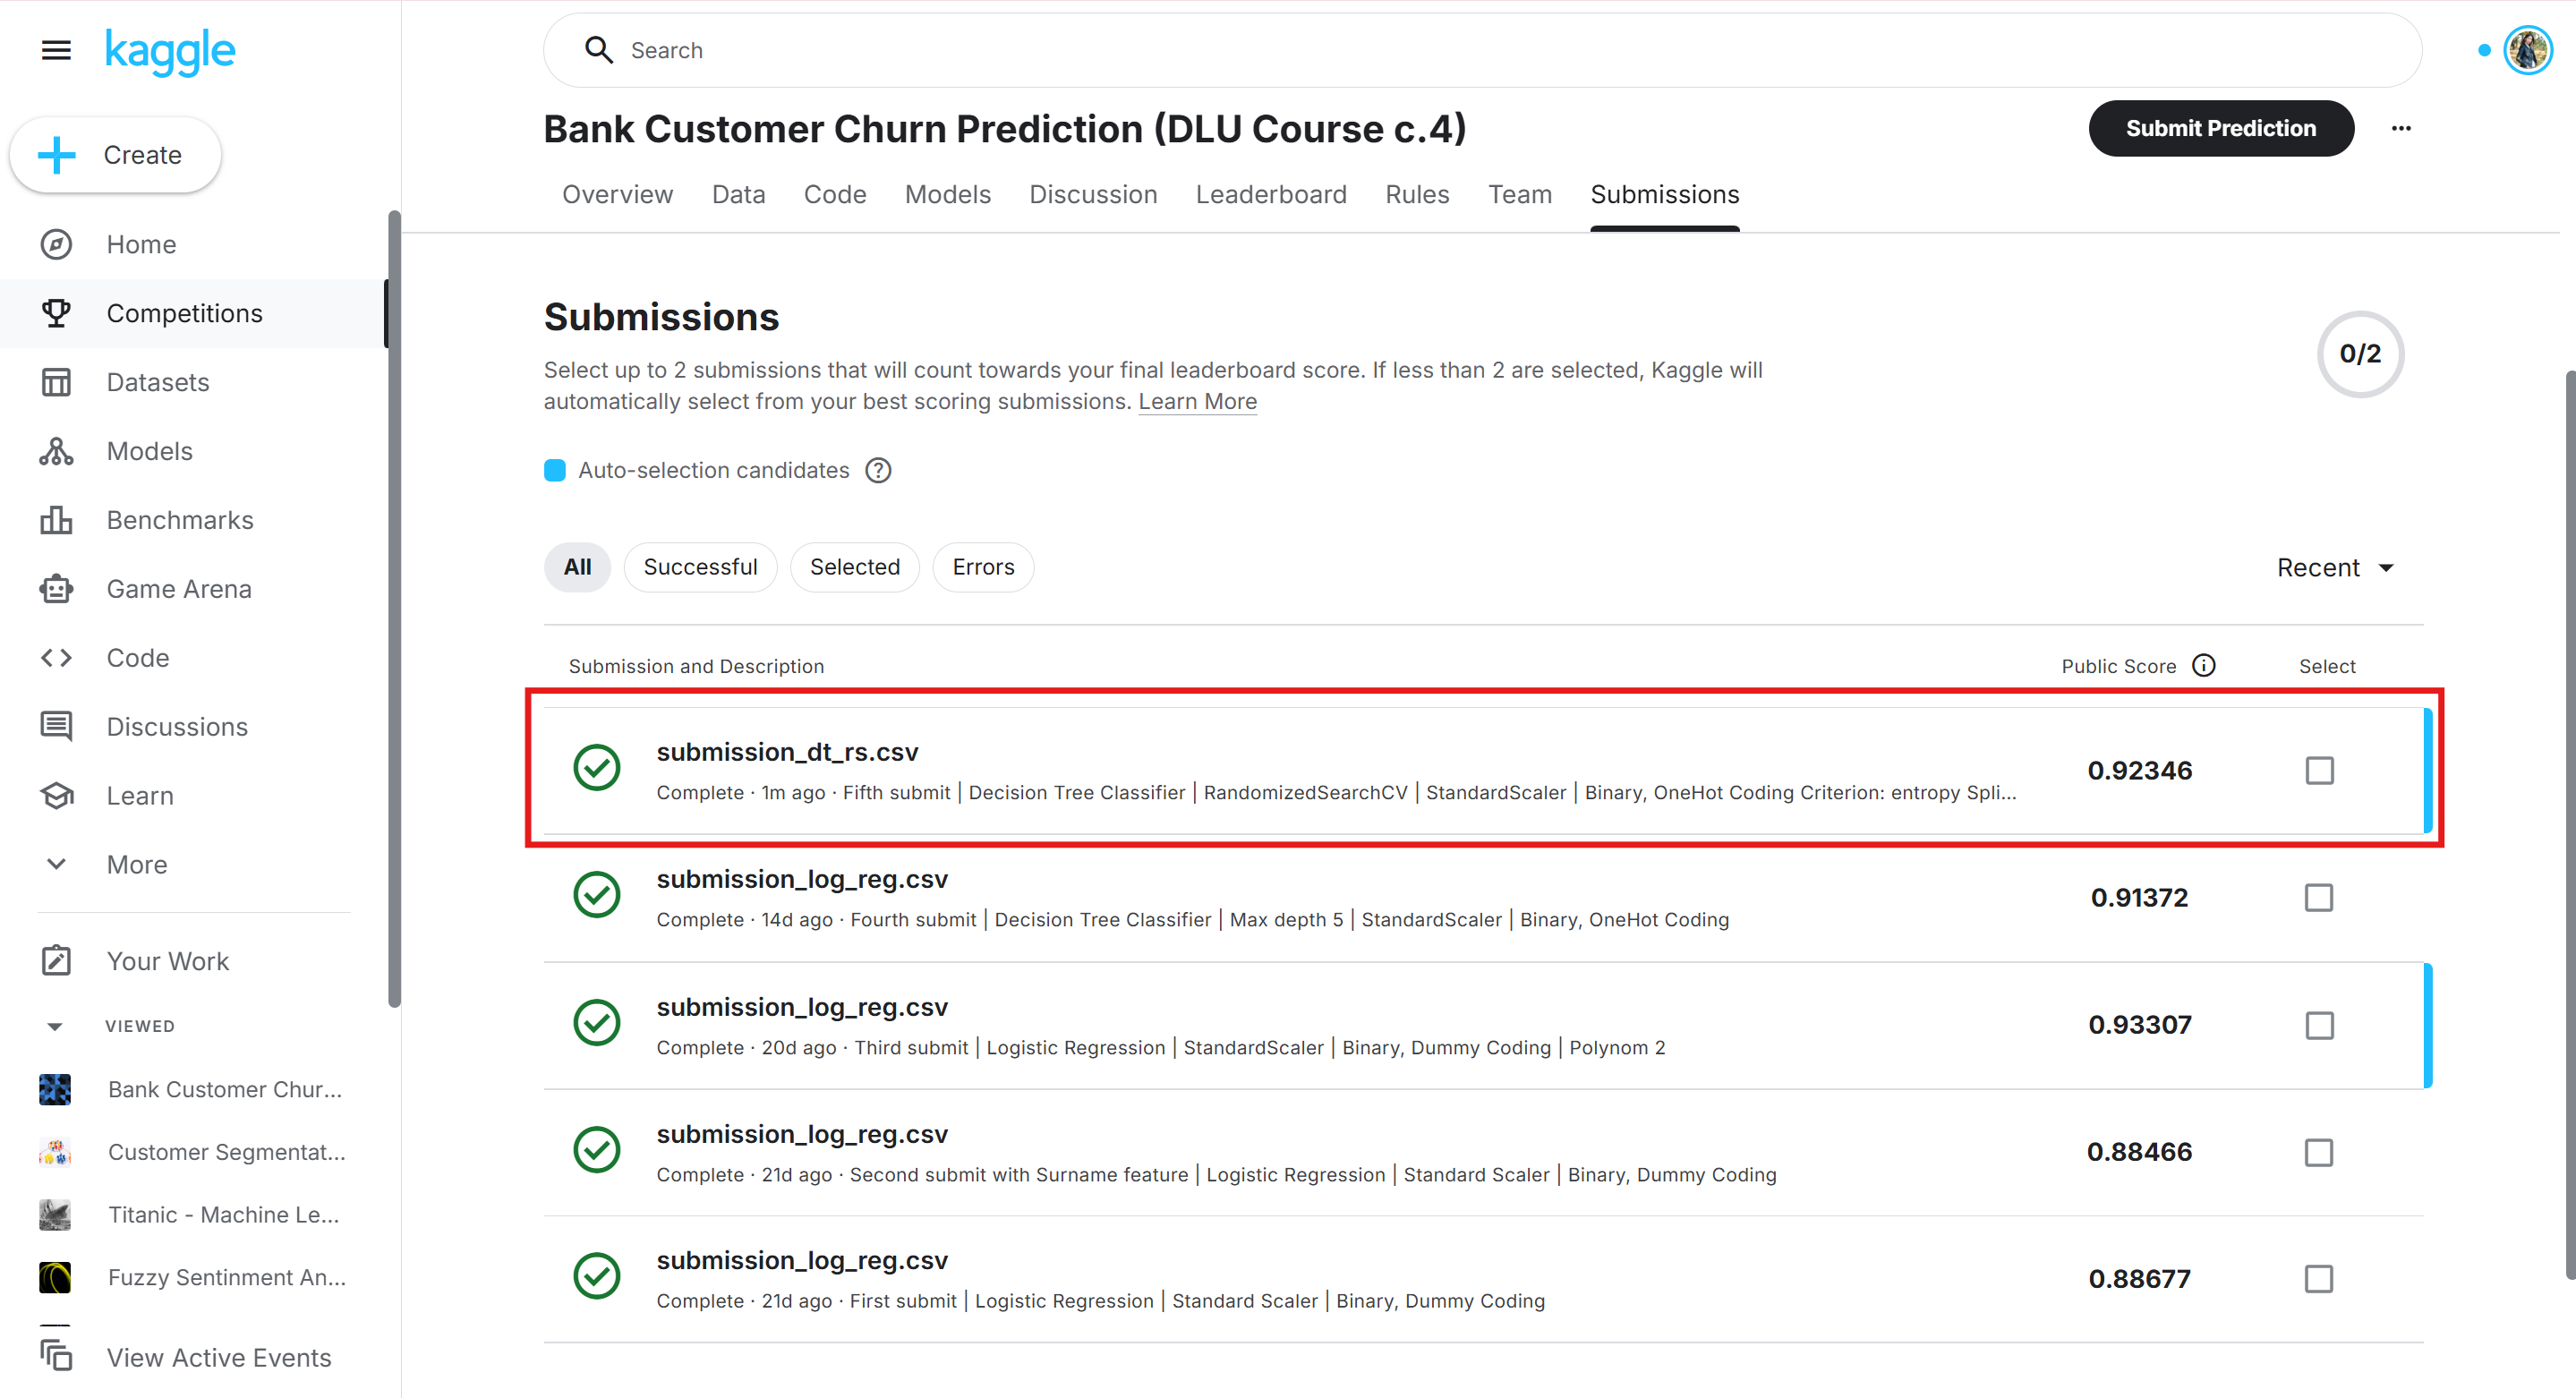